# 02 — kNN: Vectorized Distance Computation

[The previous notebook](./01_cifar10_knn_distances.ipynb) computed every query–training distance with two Python loops. Here we preserve the same mathematics while moving work into optimized NumPy operations.

## Learning objectives

- implement pairwise squared Euclidean distances with one loop;
- derive a fully vectorized implementation using matrix multiplication;
- reason about shapes before writing an expression;
- verify optimized code against a simple reference implementation;
- compare runtime and intermediate-memory requirements.

Prediction and voting for arbitrary `k` are intentionally deferred to [the next notebook](./03_knn_prediction_and_validation.ipynb).

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

## 1. Prepare the same kind of CIFAR-10 subsets

Only the official training split is needed here. We create stored and query subsets with a seeded permutation, then flatten and convert pixels to `float32`.

In [2]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
X_full = dataset.data

NUM_STORED = 1_000
NUM_QUERY = 100
indices = rng.permutation(len(X_full))
stored_indices = indices[:NUM_STORED]
query_indices = indices[NUM_STORED:NUM_STORED + NUM_QUERY]

X_stored = X_full[stored_indices].reshape(NUM_STORED, -1).astype(np.float32)
X_query = X_full[query_indices].reshape(NUM_QUERY, -1).astype(np.float32)

assert not np.isin(stored_indices, query_indices).any()
print("stored:", X_stored.shape, X_stored.dtype)
print("queries:", X_query.shape, X_query.dtype)

stored: (1000, 3072) float32
queries: (100, 3072) float32


## 2. Two-loop reference

A simple implementation is valuable even when it is slow: it provides a readable reference against which optimized versions can be checked.

In [3]:
def validate_pairwise_inputs(X_query: np.ndarray, X_stored: np.ndarray) -> None:
    if X_query.ndim != 2 or X_stored.ndim != 2:
        raise ValueError("Inputs must be two-dimensional")
    if X_query.shape[1] != X_stored.shape[1]:
        raise ValueError("Query and stored examples must have equal feature dimensions")


def squared_distances_two_loops(X_query: np.ndarray, X_stored: np.ndarray) -> np.ndarray:
    validate_pairwise_inputs(X_query, X_stored)
    distances = np.empty((len(X_query), len(X_stored)), dtype=np.float32)
    for query_index, query in enumerate(X_query):
        for stored_index, stored in enumerate(X_stored):
            distances[query_index, stored_index] = np.sum((query - stored) ** 2)
    return distances

## 3. Exercise 1 — One-loop distances

Loop over query examples only. Inside the loop, subtract one query vector from the entire `(N_stored, D)` matrix and sum over the feature axis.

Before implementing, write down the shapes of:

- `query`;
- `X_stored`;
- `X_stored - query`;
- the result after summing squared differences.

In [8]:
X_query.shape, X_stored.shape, X_query[0].shape, (X_stored - X_query[0]).shape

((100, 3072), (1000, 3072), (3072,), (1000, 3072))

In [9]:
def squared_distances_one_loop(X_query: np.ndarray, X_stored: np.ndarray) -> np.ndarray:
    """Compute pairwise squared distances using one Python loop."""
    validate_pairwise_inputs(X_query, X_stored)
    
    distances = np.empty((len(X_query), len(X_stored)), dtype=np.float32)
    for query_index, query in enumerate(X_query):
        distances[query_index] = np.sum((X_stored - query) ** 2, axis=1)

    return distances

## 4. From distances to matrix multiplication

Expanding the squared Euclidean distance gives

For one query \(x\) and one stored vector \(z\):

$$
\lVert x-z \rVert^2
= (x-z)^T(x-z)
= x^Tx + z^Tz - 2x^Tz.
$$

For matrices `X_query` with shape `(Q, D)` and `X_stored` with shape `(S, D)`:

- query squared norms have shape `(Q, 1)`;
- stored squared norms have shape `(S,)` or `(1, S)`;
- `X_query @ X_stored.T` has shape `(Q, S)`;
- broadcasting combines them into the required `(Q, S)` matrix.

This avoids constructing a `(Q, S, D)` array of pairwise pixel differences.

### L1 distance: another common choice

The [CS231n kNN demo](http://vision.stanford.edu/teaching/cs231n-demos/knn/) also allows **L1 distance**, sometimes called Manhattan distance:

$$d_1(x,z)=\sum_{p=1}^{D}|x_p-z_p|.
$$

The L2 distance used in this notebook is Euclidean distance:

$$d_2(x,z)=\sqrt{\sum_{p=1}^{D}(x_p-z_p)^2}.
$$

For example, if $x=[1,2]$ and $z=[3,5]$, then $d_1=|1-3|+|2-5|=5$, while $d_2=\sqrt{(-2)^2+(-3)^2}=\sqrt{13}$. L1 adds absolute coordinate differences; L2 emphasizes larger individual differences because they are squared.

Both metrics can produce different nearest neighbors and decision boundaries. Feature scaling matters for both: a feature with a much larger numeric range can dominate the distance. The matrix identity below is specific to squared L2 distance. L1 can still be vectorized with broadcasting, but doing so naively creates the large `(Q, S, D)` intermediate discussed later.

### A small numerical example

A vector's Euclidean **norm** is its length. For $x=[1,2]$,

$$\lVert x\rVert_2 = \sqrt{1^2+2^2}=\sqrt{5}.
$$

Its **squared norm** is therefore $\lVert x\rVert_2^2=1^2+2^2=5$. That is why summing the squared features of each row produces the row's squared norm. We use squared norms because we are computing squared distances, so no square root is needed.

Consider two query vectors and three stored vectors, each with two features:

$$X_q=\begin{bmatrix}1&2\\0&1\end{bmatrix},\qquad
X_s=\begin{bmatrix}3&4\\1&0\\-1&2\end{bmatrix}.
$$

Their row-wise squared norms are $[5,1]^T$ and $[25,1,5]$. Their cross-product matrix is

$$X_qX_s^T=\begin{bmatrix}11&1&3\\4&0&2\end{bmatrix}.
$$

Entry $(i,j)$ of this matrix is the dot product between query $i$ and stored vector $j$. The norm vectors broadcast across columns and rows:

$$
\begin{bmatrix}5\\1\end{bmatrix}
+\begin{bmatrix}25&1&5\end{bmatrix}
-2\begin{bmatrix}11&1&3\\4&0&2\end{bmatrix}
=\begin{bmatrix}8&4&4\\18&2&2\end{bmatrix}.
$$

For example, the top-left entry is $5+25-2(11)=8$, which matches the direct calculation $(1-3)^2+(2-4)^2=8$.

In [41]:
example_query = np.array([[1, 2], [0, 1]])
example_stored = np.array([[3, 4], [1, 0], [-1, 2]])

query_squared_norms = np.sum(example_query**2, axis=1, keepdims=True)
stored_squared_norms = np.sum(example_stored**2, axis=1, keepdims=True).T
cross_products = example_query @ example_stored.T
example_distances = query_squared_norms + stored_squared_norms - 2 * cross_products

print("query squared norms:\n", query_squared_norms)
print("stored squared norms:\n", stored_squared_norms)
print("cross products:\n", cross_products)
print("squared distances:\n", example_distances)
np.testing.assert_array_equal(example_distances, [[8, 4, 4], [18, 2, 2]])

query squared norms:
 [[5]
 [1]]
stored squared norms:
 [[25  1  5]]
cross products:
 [[11  1  3]
 [ 4  0  2]]
squared distances:
 [[ 8  4  4]
 [18  2  2]]


## 5. Exercise 2 — Fully vectorized distances

Implement the expanded identity without Python loops. Do not construct `X_query[:, None, :] - X_stored[None, :, :]`; although vectorized syntactically, that creates a potentially enormous three-dimensional intermediate.

Floating-point roundoff can produce tiny negative results for distances that should be zero. Finish by clipping the result to a minimum of zero.

In [33]:
def squared_distances_no_loops(X_query: np.ndarray, X_stored: np.ndarray) -> np.ndarray:
    """Compute pairwise squared distances without Python loops."""
    validate_pairwise_inputs(X_query, X_stored)

    # 1. Calculate the sum of the squares of the rows for each matrix:
    # We get the column vector (Q, 1)
    sq_norm_query = np.sum(X_query**2, axis=1, keepdims=True)
    # We get the row vector (1, S)
    sq_norm_stored = np.sum(X_stored**2, axis=1, keepdims=True).T

    # 2. Calculate the scalar product: form (Q, S)
    dot_product = X_query @ X_stored.T

    # 3. With keepdims=True, NumPy will automatically expand (Q, 1) and (1, S) to (Q, S)
    distances = sq_norm_query + sq_norm_stored - 2 * dot_product

    # protection against tiny negative values caused by floating-point roundoff
    return np.maximum(distances, 0)


## 6. Correctness before performance

First compare all implementations on small random arrays. `assert_allclose` is appropriate because different floating-point operation orders may cause small numerical differences.

In [34]:
small_query = rng.normal(size=(4, 7)).astype(np.float32)
small_stored = rng.normal(size=(6, 7)).astype(np.float32)

reference = squared_distances_two_loops(small_query, small_stored)
one_loop = squared_distances_one_loop(small_query, small_stored)
no_loops = squared_distances_no_loops(small_query, small_stored)

np.testing.assert_allclose(one_loop, reference, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(no_loops, reference, rtol=1e-5, atol=1e-5)
assert np.all(no_loops >= 0)
print("All implementations agree on the small example.")

All implementations agree on the small example.


### Exercise 3 — Stronger correctness checks

Add checks for all three properties:

1. comparing a matrix with itself produces zeros on the diagonal;
2. swapping query and stored inputs transposes the result;
3. empty query input produces shape `(0, N_stored)`.

In [35]:
squared_distances_no_loops(small_stored, small_stored).round(0)

array([[ 0.,  8., 11.,  8., 31., 33.],
       [ 8.,  0., 12.,  8., 21., 15.],
       [11., 12.,  0., 20.,  9., 15.],
       [ 8.,  8., 20.,  0., 27., 25.],
       [31., 21.,  9., 27.,  0.,  4.],
       [33., 15., 15., 25.,  4.,  0.]], dtype=float32)

In [36]:
self_distances = squared_distances_no_loops(small_stored, small_stored)
np.testing.assert_allclose(
    np.diag(self_distances),
    np.zeros(len(small_stored)),
    atol=1e-5,
)

np.testing.assert_allclose(
    squared_distances_no_loops(small_query, small_stored),
    squared_distances_no_loops(small_stored, small_query).T,
    rtol=1e-5,
    atol=1e-5
)

assert squared_distances_no_loops(np.empty((0, small_stored.shape[1])), small_stored).shape == (0, small_stored.shape[0])

print("Exercise 3 passed")

Exercise 3 passed


## 7. Measure runtime

Timing is noisy, so run each function several times and report the median. We use only ten queries for the two-loop baseline, then use the same inputs for every implementation so the comparison is fair.

In [27]:
def median_runtime(function, *args, repeats: int = 5) -> float:
    durations = []
    for _ in range(repeats):
        start = perf_counter()
        function(*args)
        durations.append(perf_counter() - start)
    return float(np.median(durations))


timing_query = X_query[:10]
implementations = {
    "two loops": squared_distances_two_loops,
    "one loop": squared_distances_one_loop,
    "no loops": squared_distances_no_loops,
}
runtimes = {
    name: median_runtime(function, timing_query, X_stored)
    for name, function in implementations.items()
}

for name, duration in runtimes.items():
    print(f"{name:>9}: {duration * 1_000:8.2f} ms")

two loops:    27.52 ms
 one loop:    15.88 ms
 no loops:     2.71 ms


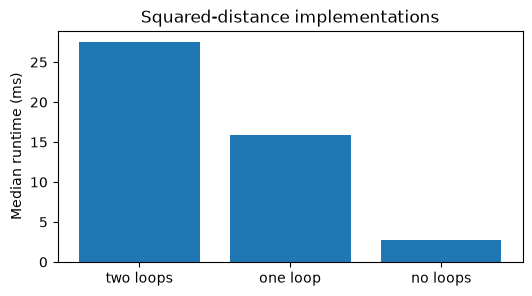

In [28]:
fig, axis = plt.subplots(figsize=(6, 3))
axis.bar(runtimes.keys(), [value * 1_000 for value in runtimes.values()])
axis.set_ylabel("Median runtime (ms)")
axis.set_title("Squared-distance implementations")
plt.show()

## 8. Exercise 4 — Memory reasoning

For `Q=100`, `S=1000`, `D=3072`, calculate the number of elements and approximate memory in MiB for a `float32` intermediate with shape `(Q, S, D)`. Recall that `float32` uses four bytes and one MiB is `1024**2` bytes.

Then compare it with the `(Q, S)` distance matrix. Write both calculations in a new Markdown cell; do not allocate the three-dimensional array.

In [30]:
(100*1000*3072*4)/(1024**2), (100*1000*4)/(1024**2)

(1171.875, 0.3814697265625)

The three-dimensional approach needs about 3,072 times more memory—roughly 1.14 GiB versus 0.38 MiB

In [31]:
# Optional: use these constants to check your arithmetic without allocating arrays.
Q, S, D = NUM_QUERY, NUM_STORED, X_stored.shape[1]
BYTES_PER_FLOAT32 = np.dtype(np.float32).itemsize
print("Q, S, D:", Q, S, D)
print("bytes per float32:", BYTES_PER_FLOAT32)

Q, S, D: 100 1000 3072
bytes per float32: 4


## Reflection

Add a Markdown cell answering:

1. Which axis is eliminated in the one-loop implementation, and which operation eliminates it?
2. Explain the shapes in the no-loop formula and how broadcasting produces `(Q, S)`.
3. Why is the two-loop version still useful even if it is slow?
4. Why do we use approximate rather than exact equality for the three results?
5. Does "no Python loops" necessarily mean "uses little memory"? Explain using Exercise 4.

1. For one query: X_stored - query has shape: (S, D) - (D,) → (S, D). Then: np.sum(..., axis=1) sums over the feature dimension D. That axis disappears, producing (S,): one distance to every stored image. So, Broadcasting eliminates the need for the Python loop over stored images and sum(axis=1) reduces/eliminates the feature axis.
2. we get (Q, S) cause query squared is (Q, 1), store squared (1, S) and query@stored.T is (Q, S). Each query norm is repeated across all stored examples, while each stored norm is repeated across all queries.
3. to check if the optimal implementation result match
4. cause floating point operation might cause small numerical differences
5. no, removing Python loops does not necessarily make an implementation memory-efficient. Vectorized code can create enormous intermediate arrays. The expanded matrix formula is both vectorized and much more memory-efficient.